# Equação do calor em uma barra infinita (reta toda)

Podemos usar as células abaixo para animar soluções da equação do calor em uma barra infinita

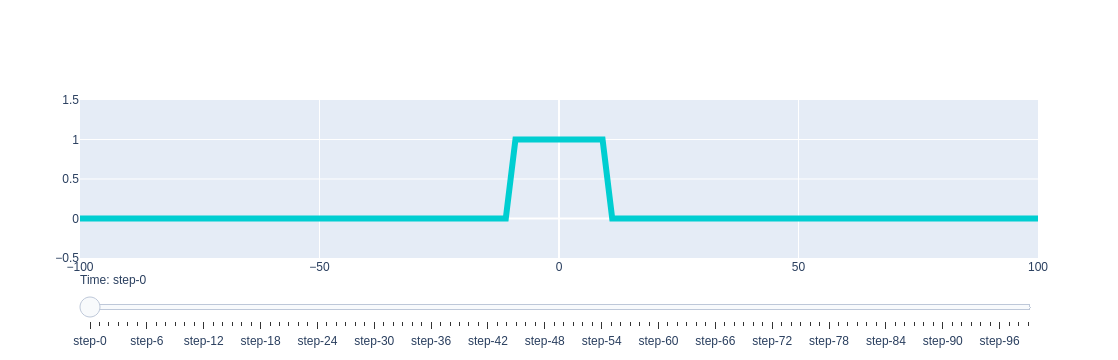

In [10]:
import numpy as np
import plotly.graph_objects as go


#difusividade térmica c**2
c = 1


#limite da integral
M = 100

# variável do comprimento

numpoints = 100
x = np.linspace(-M,M,numpoints)


# variável do tempo em segundos
N=25
t_max = 10
t = np.linspace(0,t_max)


# Condição inicial
#f = np.exp(-x**2)
f = np.piecewise(x, [x < -10, (x>-10) & (x<10), x>10], [0,1,0])
#f = np.piecewise(x, [x < 0, x >= 0], [0, 1])



# Calculando a solução
def sol(x, tt):
    if tt ==0:
        sol= f
    else:
        sol = np.zeros(len(x))
        for i in range(len(x)):
            for j in range(len(x)):
                sol[i] = sol[i]+f[j]*np.exp(-(x[i]-x[j])**2/(4*c**2*tt))
        sol = sol/np.sqrt(np.pi*tt)/numpoints*M/c
    return sol
"""
sol = np.zeros((len(x),len(t)))
sol[:,0] = f
for k in range(1,len(t)):
    for i in range(len(x)):
        for j in range(len(x)):
            sol[i,k] = sol[i,k]+f[j]*np.exp(-(x[i]-x[j])**2/(4*c**2*t[k]))
    sol[i,k] = sol[i,k]/np.sqrt(np.pi*t[k])/numpoints*2*M
"""


# Create figure
ymin = -0.5 #mínimo para eixo y
ymax = 1.5 #máximo para eixo y
fig = go.Figure(layout_yaxis_range=[ymin, ymax])


# Add traces, one for each slider step
for step in np.arange(0, t_max, 0.1):
    trace=go.Scatter(
            visible=False,
            line=dict(color="#00CED1", width=6),
            name="𝜈 = " + str(step),
            y = sol(x,step),
            x=x
        )
    fig.add_trace(
        trace)

# Make 10th trace visible
fig.data[0].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": "Time: " + str(i/10)}],  # layout attribute
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Time: "},
    pad={"t": 10},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()


In [ ]:
%%html
<iframe style="margin-top:0px;margin-left:-20px;" src="https://python-fiddle.com/" width="1200" height="600"></iframe>

Podemos usar as células abaixo para animar soluções da equação do calor em uma barra infinita (0,00)

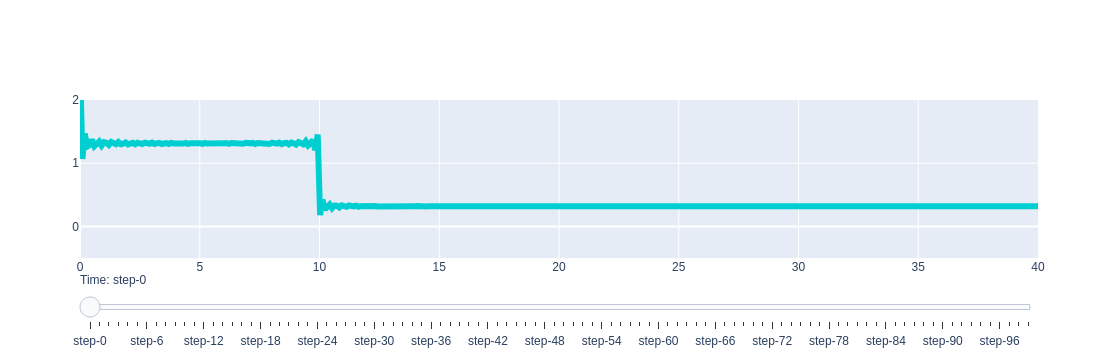

In [16]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

#Barra no semi-eixo

#Temperatura zero na extremidade - transformada de senos
#Isolada na extremidade - transformada de cossenos



#velocidade de propagação
c = 1


#limite da integral
M = 40

# variável do comprimento

numpoints = 400
x = np.linspace(0,M,numpoints)


# variável do tempo em segundos
N=25
t_max = 10
t = np.linspace(0,t_max,N)


# Condição inicial
#f = np.exp(-x**2)
f = np.piecewise(x, [x < 10, x >= 10], [1, 0])


# Calculando a transformada de senos ou cossenos
def T_f(f,x):
    t_f = np.zeros(len(x))
    for j in range(len(x)):
        for i in range(len(x)):
            #t_f[i] =  t_f[i]+f[j]*np.sin(x[j]*x[i])
            t_f[i] =  t_f[i]+f[j]*np.cos(x[j]*x[i])
    t_f = t_f*np.sqrt(2/np.pi)/numpoints*M
    return t_f

t_f = T_f(f,x)

#fig = px.line(x=x,y=t_f)
#fig.show()

# Calculando a solução
def sol(x, tt, t_f):
    sol = np.zeros(len(x))
    for j in range(len(x)):
        for i in range(len(x)):
            #sol[i] = sol[i]+t_f[j]*np.exp(-x[j]**2*c**2*tt)*np.sin(x[j]*x[i])
            sol[i] = sol[i]+t_f[j]*np.exp(-x[j]**2*c**2*tt)*np.cos(x[j]*x[i])
    sol = sol*np.sqrt(2/np.pi)/numpoints*M
    return sol


# Create figure
ymin = -0.5 #mínimo para eixo y
ymax = 2 #máximo para eixo y
fig = go.Figure(layout_yaxis_range=[ymin, ymax])


# Add traces, one for each slider step
for step in np.arange(0, t_max, 0.1):
    trace=go.Scatter(
            visible=False,
            line=dict(color="#00CED1", width=6),
            name="𝜈 = " + str(step),
            y = sol(x,step,t_f),
            x=x
        )
    fig.add_trace(
        trace)

# Make 10th trace visible
fig.data[0].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": "Time: " + str(i/10)}],  # layout attribute
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Time: "},
    pad={"t": 10},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()